# Telco Customer Churn Analysis

### Objective
The objective of this project is to analyze customer churn patterns and identify factors that influence customer retention.

### Dataset
The dataset contains 7043 customer records with demographic, service usage, billing, and churn information.

-----------------------------------------------

### Importing libraries

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

----------------------------------
### Load the dataset

In [49]:
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


### Observation

The dataset contains customer demographics, service subscriptions, billing information, and churn status.

-----------------------

### Dataset Overview

In [50]:
print("Shape:",df.shape,"\n")
print("Size:",df.size,"\n")
print("Info:",df.info())

Shape: (7043, 33) 

Size: 232419 

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  

### Key Findings

- Dataset contains 7043 records.
- Majority of columns are categorical.
- Churn Reason contains missing values.
- No major datatype issues observed initially.

--------------------------------------------

### Data Quality Assessment

In [51]:
df.nunique().sort_values()

Count                   1
Country                 1
State                   1
Phone Service           2
Dependents              2
Partner                 2
Senior Citizen          2
Gender                  2
Churn Value             2
Paperless Billing       2
Churn Label             2
Multiple Lines          3
Internet Service        3
Online Backup           3
Online Security         3
Tech Support            3
Contract                3
Streaming Movies        3
Streaming TV            3
Device Protection       3
Payment Method          4
Churn Reason           20
Tenure Months          73
Churn Score            85
City                 1129
Monthly Charges      1585
Longitude            1651
Latitude             1652
Lat Long             1652
Zip Code             1652
CLTV                 3438
Total Charges        6531
CustomerID           7043
dtype: int64

In [52]:
print("Duplicate rows:",df.duplicated().sum())
print("Duplicate columns:",df.CustomerID.duplicated().sum())

Duplicate rows: 0
Duplicate columns: 0


In [53]:
pd.crosstab(df["Churn Value"],df["Churn Label"])

Churn Label,No,Yes
Churn Value,,
0,5174,0
1,0,1869


In [54]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

### Findings

- No duplicate rows found.
- Churn Reason contains missing values because non-churned customers do not have a churn reason.
- Count, Country, and State have only one unique value and may not contribute meaningful information.

-------------------------------------------

### Data Cleaning

#### 1. Missing values

In [55]:
df.isnull().sum().sort_values(ascending=False)

Churn Reason         5174
CustomerID              0
Count                   0
State                   0
Country                 0
Zip Code                0
Lat Long                0
Latitude                0
City                    0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Longitude               0
Internet Service        0
Online Security         0
Device Protection       0
Online Backup           0
Streaming TV            0
Streaming Movies        0
Contract                0
Tech Support            0
Paperless Billing       0
Payment Method          0
Total Charges           0
Monthly Charges         0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
dtype: int64

#### Observation

The only column with missing values is Churn Reason.
These missing values are expected because customers who did not churn do not have a churn reason.

---------------------------------------
#### 2. Data Type Corrections

In [56]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

df["Total Charges"].isnull().sum()

np.int64(11)

### Observation

The Total Charges column was stored as an object data type. During conversion to numeric format, a small number of invalid values were converted to missing values (NaN).

-------------------------------
#### 3. Missing Value Treatment

The missing values in Total Charges were replaced with 0. These records correspond to customers with very low or zero tenure, indicating that charges had not yet accumulated.

In [57]:
df["Total Charges"] = df["Total Charges"].fillna(0)

In [58]:
print(df["Total Charges"].dtype)
print(df["Total Charges"].isnull().sum())

float64
0


-------------------------------------------
#### 4. Irrelevant features

In [59]:
df_clean = df.copy()
df_clean = df_clean.drop(columns = ["Count","Country","State","Churn Value"])
df_clean

,CustomerID,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,86,3239,Competitor made better offer
1,9237-HQITU,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,67,2701,Moved
2,9305-CDSKC,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,86,5372,Moved
3,7892-POOKP,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,84,5003,Moved
4,0280-XJGEX,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,No,No,No,...,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No,45,5306,NaN
7039,6840-RESVB,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,No,Yes,Yes,...,Yes,One year,Yes,Mailed check,84.80,1990.50,No,59,2140,NaN
7040,2234-XADUH,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,No,Yes,Yes,...,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,71,5560,NaN
7041,4801-JZAZL,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,No,Yes,Yes,...,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,59,2793,NaN


### Features Removed

- Count: Contains only one value.
- Country: Contains only one country.
- State: Contains only one state.
- Churn Value: Duplicate representation of Churn Label.


------------------------------------------------------------
#### 5. Dataset After Cleaning


In [60]:
print(df_clean.shape)
df_clean.info()

(7043, 29)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   City               7043 non-null   str    
 2   Zip Code           7043 non-null   int64  
 3   Lat Long           7043 non-null   str    
 4   Latitude           7043 non-null   float64
 5   Longitude          7043 non-null   float64
 6   Gender             7043 non-null   str    
 7   Senior Citizen     7043 non-null   str    
 8   Partner            7043 non-null   str    
 9   Dependents         7043 non-null   str    
 10  Tenure Months      7043 non-null   int64  
 11  Phone Service      7043 non-null   str    
 12  Multiple Lines     7043 non-null   str    
 13  Internet Service   7043 non-null   str    
 14  Online Security    7043 non-null   str    
 15  Online Backup      7043 non-null   str    
 16  Device Protection  7043 

### Result

The dataset was cleaned by removing redundant and non-informative features while retaining customer behavior and service-related information.

Original Dataset : (7043, 33)

After Cleaning : (7043, 29)

----------------------------------------------


### Outlier Detection and Treatment

Identify potential outliers in numerical features using the Interquartile Range (IQR) method and determine whether treatment is required.

####   -> Tenure Months

##### 1. Visualising

<Axes: ylabel='Tenure Months'>

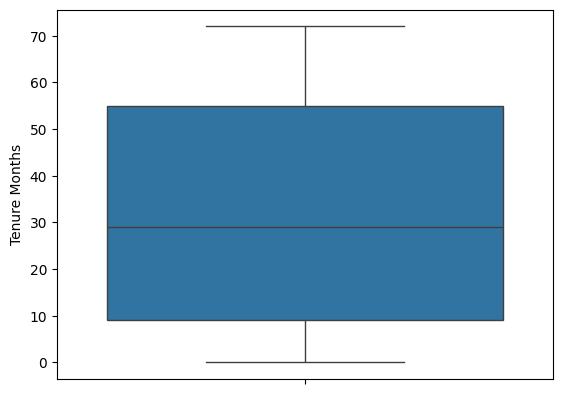

In [61]:
sns.boxplot(df_clean["Tenure Months"])

##### 2. IQR calculation

In [62]:
## IQR method
tm_Q1,tm_Q3 = np.percentile(df_clean["Tenure Months"],[25,75])
tm_IQR = tm_Q3 - tm_Q1
lower = tm_Q1 - 1.5*tm_IQR
upper = tm_Q3 + 1.5*tm_IQR 

##### 3. Finding outliers using IQR
 

In [63]:
print("No. of outliers:",df_clean[(df_clean["Tenure Months"] < lower) | (df_clean["Tenure Months"] > upper)].count().sum())

No. of outliers: 0


#### Result

0 outliers were identified in the Tenure Months feature using the IQR method.

####  -> Monthly Charges

##### 1. Visualisation

<Axes: ylabel='Monthly Charges'>

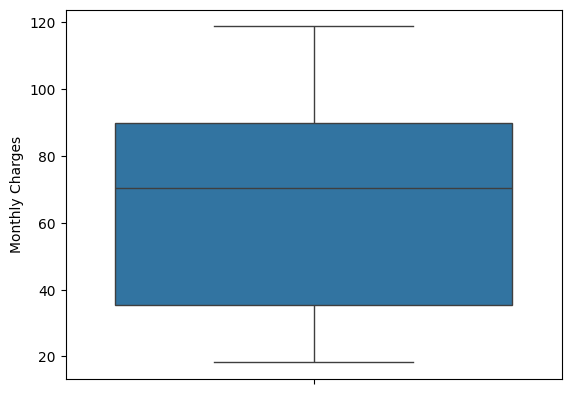

In [64]:
sns.boxplot(df_clean["Monthly Charges"])

##### 2. IQR calculation

In [65]:
## IQR method
mc_Q1,mc_Q3 = np.percentile(df_clean["Monthly Charges"],[25,75])
mc_IQR = mc_Q3 - mc_Q1
lower = mc_Q1 - 1.5*mc_IQR
upper = mc_Q3 + 1.5*mc_IQR 

##### 3. Finding outliers using IQR

In [66]:
print("No. of outliers:",df_clean[(df_clean["Monthly Charges"] < lower) | (df_clean["Monthly Charges"] > upper)].count().sum())

No. of outliers: 0


#### Result

0 outliers were identified in the Monthly Charges feature using the IQR method.

####  -> Total Charges

##### 1. Visualisation

<Axes: ylabel='Total Charges'>

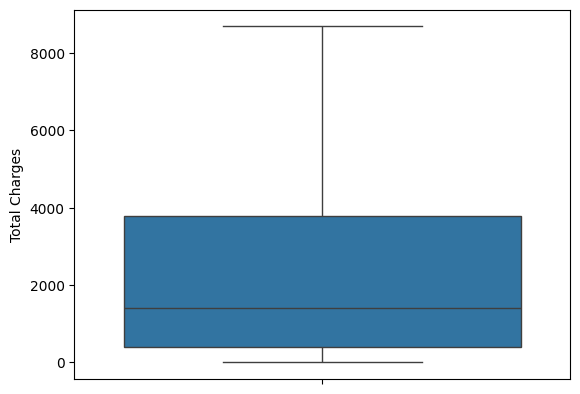

In [67]:
sns.boxplot(df["Total Charges"])

##### 2. IQR calculation

In [68]:
## IQR method
tc_Q1,tc_Q3 = np.percentile(df_clean["Total Charges"],[25,75])
tc_IQR = tc_Q3 - tc_Q1
lower = tc_Q1 - 1.5*tc_IQR
upper = tc_Q3 + 1.5*tc_IQR 

##### 3. Finding outliers using IQR

In [69]:
print("No. of outliers:",df_clean[(df_clean["Total Charges"] < lower) | (df_clean["Total Charges"] > upper)].count().sum())

No. of outliers: 0


#### Result

0 outliers were identified in the Total Charges feature using the IQR method.

####  -> Customer Lifetime Value (CLTV)

##### 1. Visualisation

<Axes: ylabel='CLTV'>

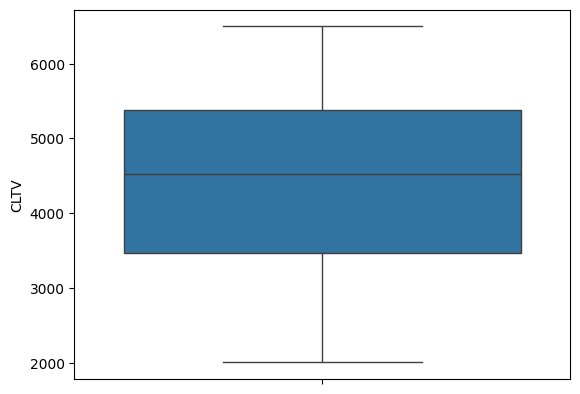

In [70]:
sns.boxplot(df_clean["CLTV"])

##### 2. IQR calculation

In [71]:
## IQR method
cl_Q1,cl_Q3 = np.percentile(df_clean["CLTV"],[25,75])
cl_IQR = cl_Q3 - cl_Q1
lower = cl_Q1 - 1.5*cl_IQR
upper = cl_Q3 + 1.5*cl_IQR 

##### 3. Finding outliers using IQR

In [72]:
print("No. of outliers:",df_clean[(df_clean["CLTV"] < lower) | (df_clean["CLTV"] > upper)].count().sum())

No. of outliers: 0


#### Result

0 outliers were identified in the CLTV feature using the IQR method.

----------------------------------

### Observation

The IQR method was applied to Tenure Months, Monthly Charge, Total Charges, and CLTV to identify potential outliers. The calculated lower and upper bounds contained all observations within the expected range. Visual inspection using boxplots further supported the absence of significant outliers.

### Conclusion

No outliers were detected in the selected numerical features. Therefore, no records were removed or modified, and the dataset was preserved in its original form for subsequent exploratory data analysis.

---------------------------
### Export Cleaned Dataset

In [73]:
df_clean.to_csv("../data/processed/telco_cleaned.csv", index=False)


### Observation

The cleaned dataset was successfully exported and saved for future analysis and subsequent internship tasks.

-------------------------------------------------------
# Exploratory Data Analysis (EDA)

#### 1. Statistical Summary

In [74]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   City               7043 non-null   str    
 2   Zip Code           7043 non-null   int64  
 3   Lat Long           7043 non-null   str    
 4   Latitude           7043 non-null   float64
 5   Longitude          7043 non-null   float64
 6   Gender             7043 non-null   str    
 7   Senior Citizen     7043 non-null   str    
 8   Partner            7043 non-null   str    
 9   Dependents         7043 non-null   str    
 10  Tenure Months      7043 non-null   int64  
 11  Phone Service      7043 non-null   str    
 12  Multiple Lines     7043 non-null   str    
 13  Internet Service   7043 non-null   str    
 14  Online Security    7043 non-null   str    
 15  Online Backup      7043 non-null   str    
 16  Device Protection  7043 non-null   

In [75]:
df_clean.describe()

,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,93521.964646,36.282441,-119.798880,32.371149,64.761692,2279.734304,58.699418,4400.295755
std,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.794470,21.525131,1183.057152
min,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,92102.000000,34.030915,-121.815412,9.000000,35.500000,398.550000,40.000000,3469.000000
50%,93552.000000,36.391777,-119.730885,29.000000,70.350000,1394.550000,61.000000,4527.000000
75%,95351.000000,38.224869,-118.043237,55.000000,89.850000,3786.600000,75.000000,5380.500000
max,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,100.000000,6500.000000


In [76]:
df_clean.describe(include='all')

,CustomerID,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Score,CLTV,Churn Reason
count,7043,7043,7043.000000,7043,7043.000000,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043.000000,7043.000000,7043,7043.000000,7043.000000,1869
unique,7043,1129,NaN,1652,NaN,NaN,2,2,2,2,...,3,3,2,4,NaN,NaN,2,NaN,NaN,20
top,3668-QPYBK,Los Angeles,NaN,"33.964131, -118.272783",NaN,NaN,Male,No,No,No,...,No,Month-to-month,Yes,Electronic check,NaN,NaN,No,NaN,NaN,Attitude of support person
freq,1,305,NaN,5,NaN,NaN,3555,5901,3641,5416,...,2785,3875,4171,2365,NaN,NaN,5174,NaN,NaN,192
mean,NaN,NaN,93521.964646,NaN,36.282441,-119.798880,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,64.761692,2279.734304,NaN,58.699418,4400.295755,NaN
std,NaN,NaN,1865.794555,NaN,2.455723,2.157889,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,30.090047,2266.794470,NaN,21.525131,1183.057152,NaN
min,NaN,NaN,90001.000000,NaN,32.555828,-124.301372,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,18.250000,0.000000,NaN,5.000000,2003.000000,NaN
25%,NaN,NaN,92102.000000,NaN,34.030915,-121.815412,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,35.500000,398.550000,NaN,40.000000,3469.000000,NaN
50%,NaN,NaN,93552.000000,NaN,36.391777,-119.730885,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,70.350000,1394.550000,NaN,61.000000,4527.000000,NaN
75%,NaN,NaN,95351.000000,NaN,38.224869,-118.043237,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,89.850000,3786.600000,NaN,75.000000,5380.500000,NaN


### Observation

- The cleaned dataset contains 7043 customer records and 29 features. The dataset includes both categorical and numerical variables related to customer demographics, service subscriptions, billing information, and churn behavior.

- The average customer tenure is approximately 32 months, while the average monthly charge is around $65. The dataset contains customers with varying service durations and billing amounts, indicating a diverse customer base.

--------------------------
#### 2. Histograms and Boxplots

##### - Tenure Months Distribution

<Axes: xlabel='Tenure Months', ylabel='Count'>

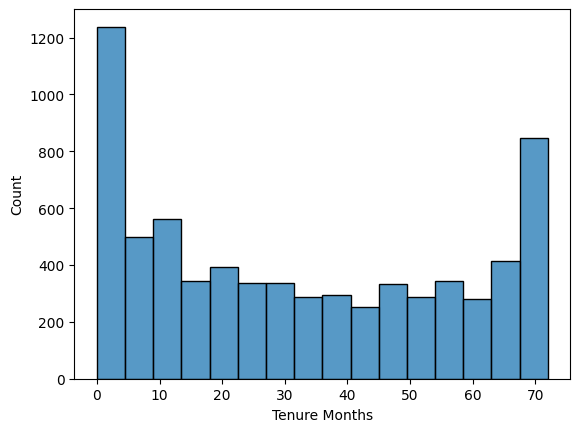

In [77]:
# Histogram
sns.histplot(df_clean["Tenure Months"])

<Axes: ylabel='Tenure Months'>

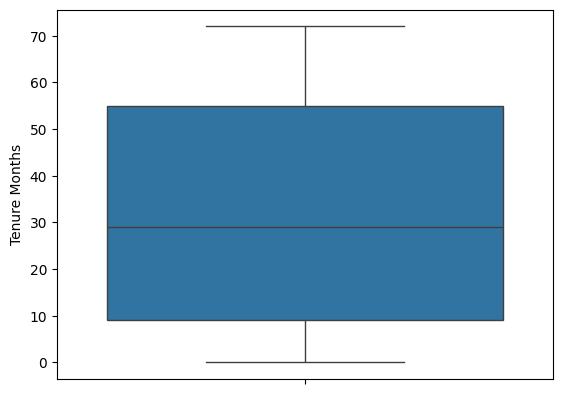

In [78]:
# Boxplot
sns.boxplot(df_clean["Tenure Months"])

#### Observations
The tenure distribution shows customers across a wide range of service durations. A significant number of customers have shorter tenures, while another group has remained with the company for a much longer period. The boxplot indicates that the feature does not contain significant outliers.

#### - Monthly Charge Distribution

<Axes: xlabel='Monthly Charges', ylabel='Count'>

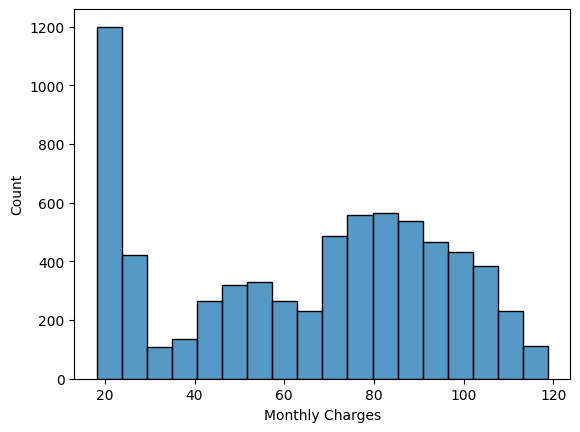

In [79]:
# Histogram
sns.histplot(df_clean["Monthly Charges"])

<Axes: ylabel='Monthly Charges'>

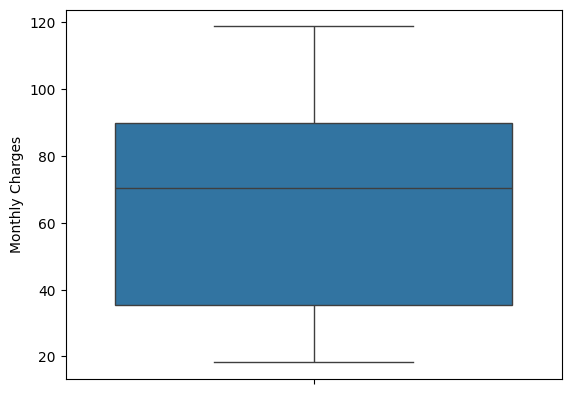

In [80]:
# Boxplot
sns.boxplot(df_clean["Monthly Charges"])

#### Observation
Monthly charges vary considerably among customers, reflecting different subscription plans and service combinations. Most customers fall within the moderate billing range, while the boxplot suggests a relatively balanced distribution without significant outliers.

### - Total Charges Distribution

<Axes: xlabel='Total Charges', ylabel='Count'>

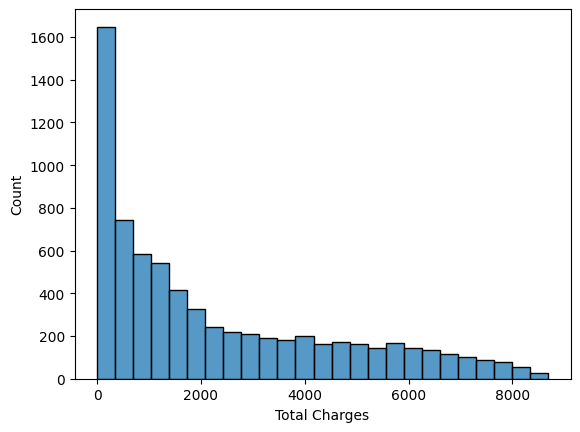

In [81]:
# Histogram
sns.histplot(df_clean["Total Charges"])

<Axes: ylabel='Total Charges'>

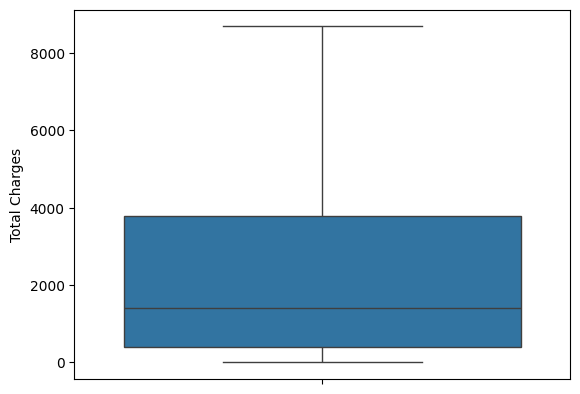

In [82]:
# Boxplot
sns.boxplot(df_clean["Total Charges"])

#### Observation
Total charges exhibit a broad distribution with a concentration of customers at lower charge levels. Higher total charges are observed among long-term customers who have accumulated charges over time. No abnormal observations were detected through the boxplot analysis.

### - Customer Lifetime Value (CLTV) Distribution

<Axes: xlabel='CLTV', ylabel='Count'>

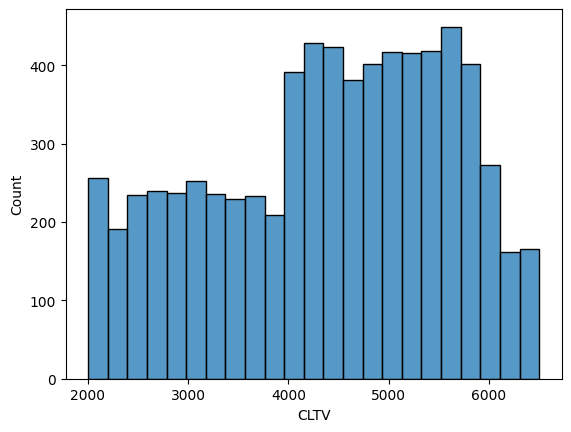

In [83]:
# Histogram
sns.histplot(df_clean["CLTV"])

<Axes: ylabel='CLTV'>

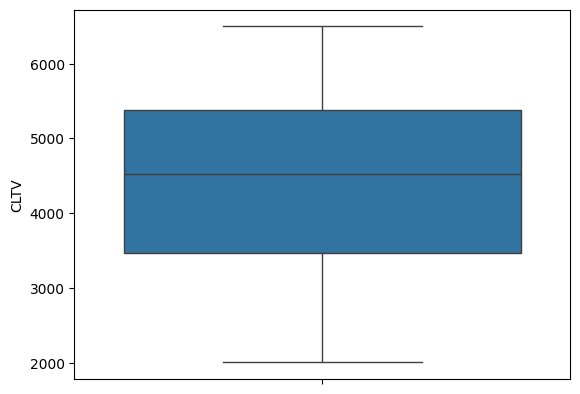

In [84]:
# Boxplot
sns.boxplot(df_clean["CLTV"])

#### Observation
Customer Lifetime Value displays considerable variation across customers. While many customers fall within a moderate value range, a smaller segment contributes substantially higher lifetime value. The distribution highlights the presence of both average and highly valuable customers.

----------------------
### Summary of Numerical Feature Analysis

The numerical features demonstrate substantial variation in customer tenure, spending behavior, and lifetime value. Customers differ significantly in their duration of service and financial contribution, indicating the presence of multiple customer segments within the dataset. No significant outliers were identified during the analysis, and all observations were retained for further exploration.

----------------------------
## Bar Charts (Categorical Comparisons)

### Objective

To analyze the distribution of categorical features and understand customer characteristics, service preferences, and billing behavior.

### - Contract Type Distribution

<Axes: xlabel='Contract', ylabel='count'>

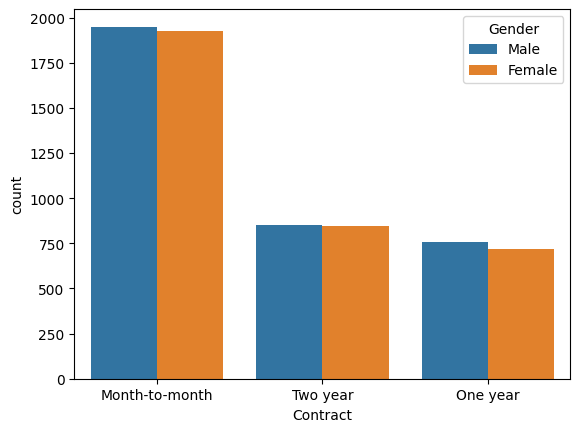

In [85]:
sns.countplot(data=df_clean, x="Contract", hue="Gender")

Month-to-month contracts represent the largest proportion of customers. Long-term contracts such as one-year and two-year plans are comparatively less common, indicating that many customers prefer flexible subscription options.

----------------------------
### - Internet Service Distribution

In [86]:
df_clean.columns

Index(['CustomerID', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
       'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

<Axes: xlabel='Internet Service', ylabel='count'>

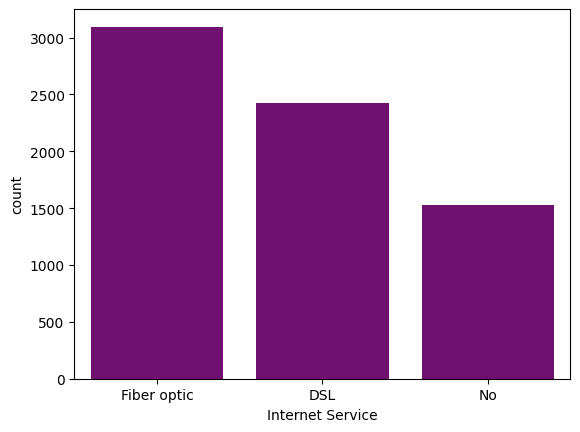

In [87]:
internet = df_clean["Internet Service"].value_counts()
sns.barplot(internet,color='purple')

Most customers subscribe to internet services, with Fiber Optic and DSL being the dominant service types. Only a small proportion of customers do not subscribe to internet services.

------------------------------
### - Payment Method Distribution

<Axes: xlabel='Payment Method', ylabel='count'>

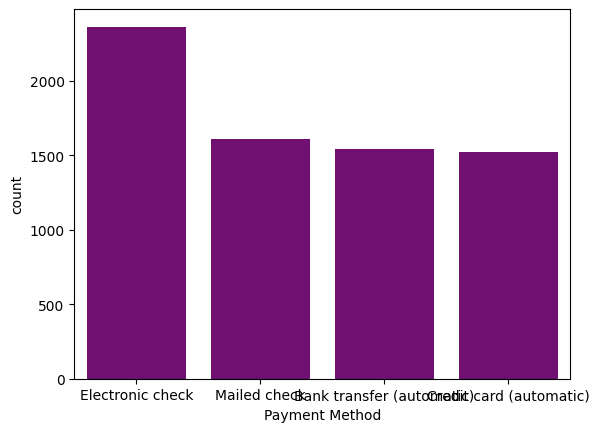

In [88]:
pm = df_clean["Payment Method"].value_counts()
sns.barplot(pm,color='purple')

Electronic check is the most frequently used payment method among customers, while mailed checks are used less frequently. This suggests a preference for electronic payment options.

-----------------------------------------

### - Gender Distribution

<Axes: xlabel='Gender', ylabel='count'>

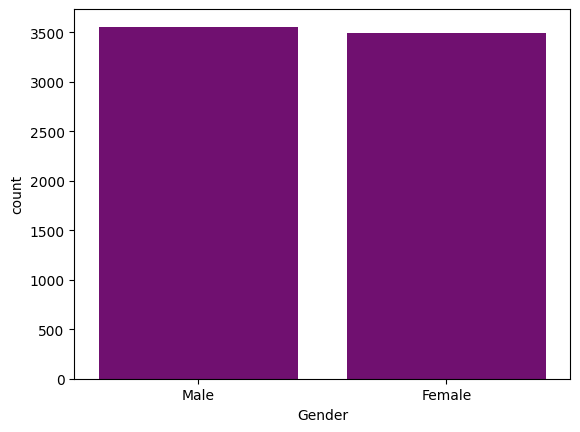

In [89]:
sns.barplot(df_clean["Gender"].value_counts(),color='purple')

The customer base is relatively balanced between male and female customers, indicating no significant gender imbalance within the dataset.

--------------------------------------
### - Senior Citizen Distribution

<Axes: xlabel='Senior Citizen', ylabel='count'>

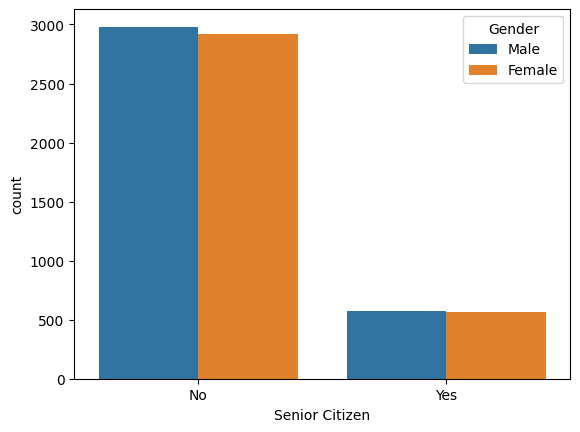

In [90]:
sns.countplot(data=df_clean,x="Senior Citizen",hue="Gender")

The majority of customers are non-senior citizens, while senior citizens represent a smaller segment of the customer base.

-----------------------------
### Summary of Categorical Analysis

The categorical analysis reveals that month-to-month contracts are the most popular subscription type, internet services are widely adopted, and electronic check is the preferred payment method. The customer base is relatively balanced by gender, while non-senior citizens constitute the majority of customers.

----------------------------

## Correlation Matrix

In [91]:
mat = df_clean[["Tenure Months","Monthly Charges","Total Charges","CLTV","Churn Score"]]
mat

,Tenure Months,Monthly Charges,Total Charges,CLTV,Churn Score
0,2,53.85,108.15,3239,86
1,2,70.70,151.65,2701,67
2,8,99.65,820.50,5372,86
3,28,104.80,3046.05,5003,84
4,49,103.70,5036.30,5340,89
...,...,...,...,...,...
7038,72,21.15,1419.40,5306,45
7039,24,84.80,1990.50,2140,59
7040,72,103.20,7362.90,5560,71
7041,11,29.60,346.45,2793,59


In [92]:
# Correlation matrix
mat.corr()

,Tenure Months,Monthly Charges,Total Charges,CLTV,Churn Score
Tenure Months,1.000000,0.247900,0.826178,0.396406,-0.224987
Monthly Charges,0.247900,1.000000,0.651174,0.098693,0.133754
Total Charges,0.826178,0.651174,1.000000,0.342091,-0.123410
CLTV,0.396406,0.098693,0.342091,1.000000,-0.079782
Churn Score,-0.224987,0.133754,-0.123410,-0.079782,1.000000


<Axes: >

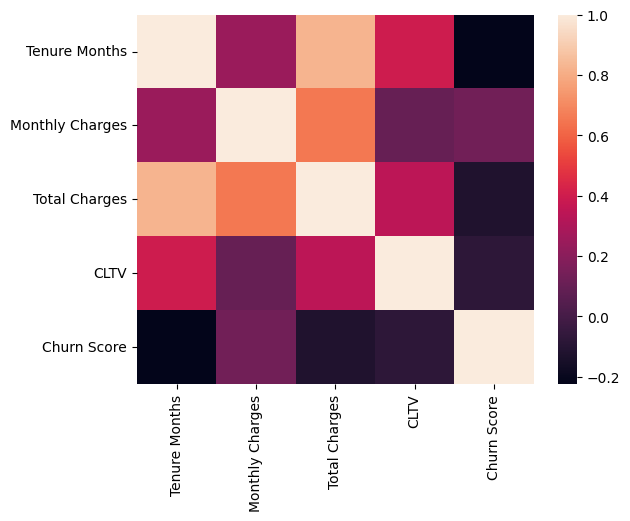

In [93]:
# Heatmap
sns.heatmap(mat.corr())

### Observation

The correlation matrix was used to examine relationships among the numerical features in the dataset.

Key findings include:

1. **Tenure Months and Total Charges** show a strong positive correlation (**0.83**), indicating that customers who remain with the company longer tend to accumulate higher total charges.

2. **Monthly Charges and Total Charges** exhibit a moderate positive correlation (**0.65**), suggesting that customers with higher monthly bills generally contribute more revenue over time.

3. **Tenure Months and CLTV** have a moderate positive correlation (**0.40**), indicating that long-term customers tend to generate greater lifetime value.

4. **Tenure Months and Churn Score** show a weak negative correlation (**-0.22**), suggesting that customers with longer tenures are generally less likely to churn.

5. **CLTV and Churn Score** have a very weak negative relationship (**-0.08**), indicating that customer lifetime value alone may not be a strong predictor of churn risk.

### Summary

The strongest relationship observed in the dataset is between Tenure Months and Total Charges. This highlights the importance of customer retention, as long-term customers contribute significantly more revenue and lifetime value to the company.

-----------------------------------
## Trend Analysis

- Tenure Months vs Average Total Charges

<Axes: xlabel='Tenure Months', ylabel='Total Charges'>

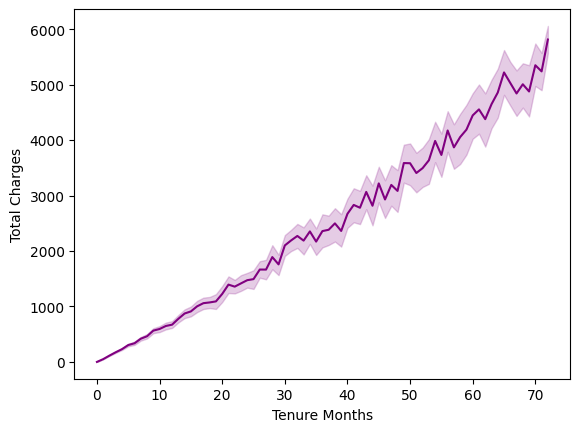

In [94]:
sns.lineplot(x=df_clean["Tenure Months"],y=df_clean["Total Charges"],estimator="mean",color="purple",)

### Observation

The line chart shows a clear upward trend between customer tenure and average total charges. Customers who stay with the company for longer periods contribute substantially higher cumulative revenue compared to newer customers.

-----------------------------------
# Key Insights

1. The average customer tenure is approximately 32 months, indicating moderate customer retention.

2. Month-to-month contracts represent the largest customer segment, suggesting a preference for flexible subscription plans.

3. Electronic check is the most commonly used payment method among customers.

4. Tenure Months and Total Charges have a strong positive correlation (0.83), showing that long-term customers generate significantly higher revenue.

5. Customer Lifetime Value increases with customer tenure, highlighting the importance of retaining existing customers.

------------------------------
# Conclusion
This project involved cleaning and analyzing the IBM Telco Customer Churn dataset containing 7043 customer records. Data quality checks identified redundant features, datatype inconsistencies, and missing values, which were addressed during preprocessing.

Exploratory Data Analysis revealed important customer characteristics, service preferences, and billing patterns. Correlation analysis showed a strong positive relationship between customer tenure and total charges, emphasizing the value of long-term customer retention.

The cleaned dataset and insights generated from this analysis provide a strong foundation for further SQL analysis, dashboard development, and predictive modeling in the upcoming tasks.